# ERA5 GEV Fit Spatial Maps

This notebook visualizes the spatial distributions and temporal trends of non-stationary Generalized Extreme Value (GEV) parameters fitted to ERA5 annual temperature extremes. It generates global maps showing the location (μ), scale (σ), and shape (ξ) parameters along with their temporal trends, providing insights into how temperature extremes and their variability are changing across the globe. The analysis covers both annual maximum and minimum temperatures at 1-degree resolution, computed relative to different anomaly types (raw data, anomalies relative to warming trend, anomalies relative to annual mean temperature).

In [1]:
# import base packages for data analysis
import xarray as xr
import matplotlib.pyplot as plt

# config
from evt_heat_waves.config import ERA5_PATH, FIGS_PATH

# import custom stuff
from evt_heat_waves.plotting.plotting_presets import get_presets
from evt_heat_waves.plotting.gev_param_plots import (
    plot_gev_parameters, print_summary, print_trend_significance)

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

save_figs = False


%load_ext autoreload
%autoreload 2

In [ ]:
# notebook defaults
save_figs = True
TMIN = 1979
GRID = '1deg'
ex_type = 'max'
nonstat_fit = 'nonstat_gumbel_only_loc_trend'
stat_fit = 'stat_gumbel'
anom_type = 'annmean'
N_params = 3

ds_stat = xr.open_dataset(
    ERA5_PATH / 'gev' / f'era5_t2m_annual_{ex_type}_{GRID}_landonly_gev_{stat_fit}_TMIN{TMIN}_{anom_type}.nc',
    engine='netcdf4'
)

ds_nonstat = xr.open_dataset(
    ERA5_PATH / 'gev' / f'era5_t2m_annual_{ex_type}_{GRID}_landonly_gev_{nonstat_fit}_TMIN{TMIN}_{anom_type}.nc',
    engine='netcdf4'
) if nonstat_fit is not None else None

fname = (f'era5-t2m-{ex_type}-{anom_type}-gev-parameters-{GRID}-{TMIN}-{stat_fit}-{nonstat_fit}-hybrid'
         if nonstat_fit is not None
         else f'era5-t2m-{ex_type}-{anom_type}-gev-parameters-{GRID}-{TMIN}-{stat_fit}')

<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Figure saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-07-14-era5-t2m-max-annmean-gev-parameters-1deg-1979-stat_gumbel-nonstat_gumbel_only_loc_trend-hybrid.png


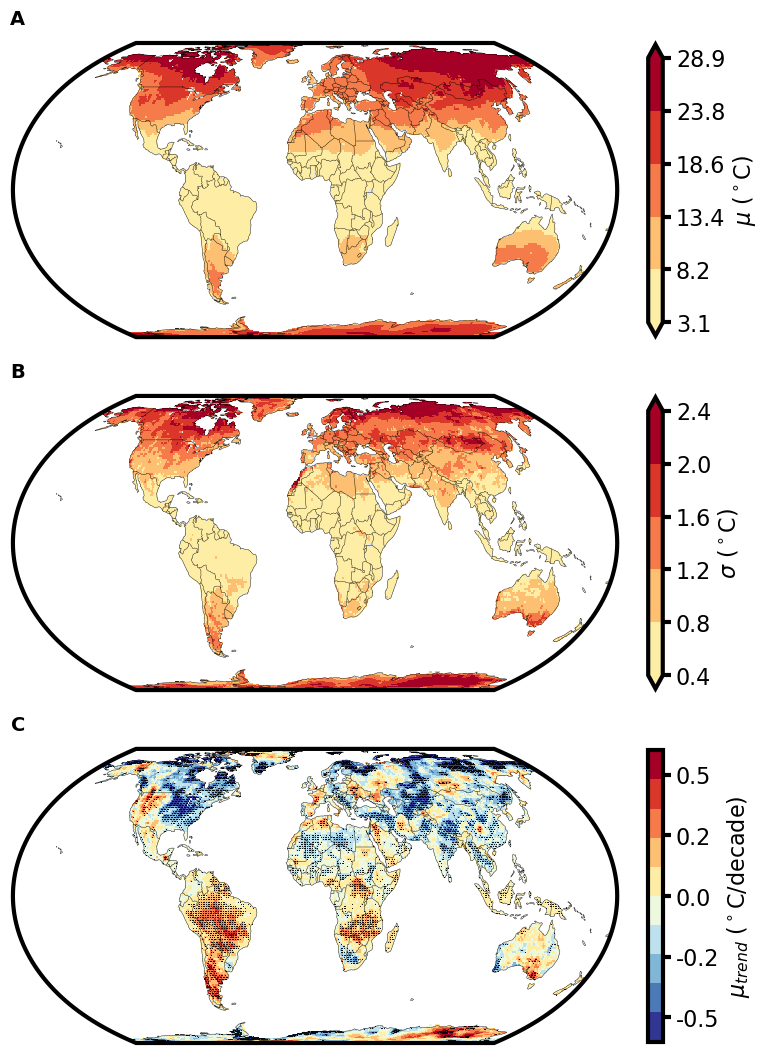

In [7]:
plot_gev_parameters(
    ds_stat, ds_nonstat, N_params=N_params, anom_type=anom_type, param_panel_order=['loc', 'scale', 'loc_t'],
    ex_type=ex_type, moments=False,
    save_figs=save_figs, fname=fname, output_dir=FIGS_PATH
)

In [4]:
print_summary(ds_stat, fit=stat_fit, anom_type=anom_type)

The area weighted average for loc is 13.664509721875552 +/- 0.17249976865843775
The area weighted average for scale is 1.1041974423230239 +/- 0.11964532470345929


In [5]:
print_summary(ds_nonstat, fit=nonstat_fit, anom_type=anom_type)

The area weighted average for loc is 13.805009553810434 +/- 0.3083571454628201
The area weighted average for loc_t is -0.2502202599452635 +/- 0.5338740132986706
The area weighted average for scale is 1.0575869422799566 +/- 0.11646055528178938


In [6]:
print_trend_significance(ds_nonstat, fit=nonstat_fit, anom_type=anom_type)


loc_t (CI: +/- 2 SE)
  Confident positive trend:   13.8% of all land  |   31.6% of positive-trend cells
  Confident negative trend:   16.9% of all land  |   30.1% of negative-trend cells
